# CEG3004:DSP Mini-Project: Environmental Sound Classification

**You will improve the DSP feature pipeline and the ML model.**

✅ Train on: `data/train` (labeled)  
✅ Predict on: `data/submission` (unlabeled; includes `__clean`, `__noisy`, `__bandlimited`)  
✅ Submit: 1) The model in `<GROUP_ID>_model.joblib` and 2) `<GROUP_ID>_predictions.csv` to xsite Dropbox

---

## Student TODO Map (what you should improve)

1. **Preprocessing** (normalization, trimming/padding, filtering etc)
2. **Feature extraction** (MFCC/log-mel/spectral features, CMVN, deltas, pooling)
3. **Modeling** (classifier choice + hyperparameters)
4. **Robustness** (augmentation ideas: noise, random bandpass, gain)

All places you should edit are marked as:

> **🟨 STUDENT TODO**


In [ ]:
#@title Enter Your Project Group Number
#@markdown This should be as per xcite Group (e.g. Pr_1)
GROUP_ID = "Pr_14" #@param {type:"string"}

if not GROUP_ID:
  raise ValueError("You must enter a Group ID to proceed. Please run this cell again.")

print(f"Welcome Group, {GROUP_ID}!")

In [ ]:
#@title 1) Setup (install deps)
!pip -q install numpy scipy pandas scikit-learn librosa soundfile tqdm


In [ ]:
#@title 2) Download dataset ZIP from Google Drive
!pip -q install gdown

import gdown
import zipfile
import os

FILE_ID = "1bceZrbOMPSXTTTMBx8XqDBwsSMussPHj"
zip_path = "CEG3004_Project_Data.zip"

gdown.download(f"https://drive.google.com/uc?id={FILE_ID}", zip_path, quiet=False)

In case the above code fails due to overload, you can manually download the data from the link [here](https://drive.google.com/file/d/1bceZrbOMPSXTTTMBx8XqDBwsSMussPHj/view?usp=sharing) and upload to colab using folder icon on the left panel. Please see the picture below


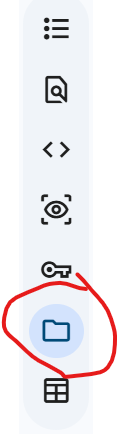

In [ ]:
#Extract the folder
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall("/content")

print("Dataset extracted.")

In [ ]:
#@title 3) Set paths (EDIT ME IF REQUIRED)
import os

# 🟨 STUDENT TODO: Set this to your Drive path
# Example: '/content/drive/MyDrive/data'
DATA_ROOT = "/content/"

TRAIN_DIR = os.path.join(DATA_ROOT, 'data', 'train')
SUBMISSION_DIR = os.path.join(DATA_ROOT, 'data', 'submission')

print('TRAIN_DIR:', TRAIN_DIR)
print('SUBMISSION_DIR:', SUBMISSION_DIR)
assert os.path.exists(TRAIN_DIR), 'Train directory not found'
assert os.path.exists(SUBMISSION_DIR), 'Submission directory not found'


In [ ]:
#@title 🔍 Dataset Safety Check (DO NOT MODIFY)

import os
import pandas as pd

print("Checking dataset structure...\n")

train_dir = os.path.join(DATA_ROOT, "data", "train")
submission_dir = os.path.join(DATA_ROOT, "data", "submission")

assert os.path.exists(train_dir), "❌ Missing data/train folder"
assert os.path.exists(submission_dir), "❌ Missing data/submission folder"

labels_path = os.path.join(train_dir, "labels.csv")
meta_path = os.path.join(submission_dir, "metadata.csv")

assert os.path.exists(labels_path), "❌ Missing labels.csv in train"
assert os.path.exists(meta_path), "❌ Missing metadata.csv in submission"

train_audio_dir = os.path.join(train_dir, "audio")
sub_audio_dir = os.path.join(submission_dir, "audio")

assert os.path.exists(train_audio_dir), "❌ Missing train/audio folder"
assert os.path.exists(sub_audio_dir), "❌ Missing submission/audio folder"

train_wavs = [f for f in os.listdir(train_audio_dir) if f.endswith(".wav")]
sub_wavs = [f for f in os.listdir(sub_audio_dir) if f.endswith(".wav")]

assert len(train_wavs) > 0, "❌ No training WAV files found"
assert len(sub_wavs) > 0, "❌ No submission WAV files found"

labels_df = pd.read_csv(labels_path)
meta_df = pd.read_csv(meta_path)

print(f"✅ Train samples: {len(labels_df)}")
print(f"✅ Submission samples: {len(meta_df)}")
print(f"✅ Train WAV files: {len(train_wavs)}")
print(f"✅ Submission WAV files: {len(sub_wavs)}")

# Check 3x robustness structure
base_ids = labels_df["clip_id"].astype(str)
expected_submission = len(base_ids) * 3

if len(meta_df) == expected_submission:
    print("✅ Submission contains clean/noisy/bandlimited versions (3x check passed)")
else:
    print("⚠️ Submission count does not match expected 3x structure")

print("\n🎉 Dataset structure looks correct.")


In [ ]:
#@title 4) Imports
import numpy as np
import pandas as pd
from tqdm import tqdm
import librosa
import soundfile as sf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score


## Load training labels

In [ ]:
labels_csv = os.path.join(TRAIN_DIR, 'labels.csv')
audio_train_dir = os.path.join(TRAIN_DIR, 'audio')

df = pd.read_csv(labels_csv)
df['clip_id'] = df['clip_id'].astype(str)
df['label'] = df['label'].astype(str)
print('Train rows:', len(df))
df.head()


In [ ]:
#@title ✅ Interactive Audio Player with Visualizations
import IPython.display as ipd
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import librosa.display

def play_audio_and_visualize(clip_id):
    row = df[df['clip_id'] == clip_id].iloc[0]
    path = os.path.join(audio_train_dir, f'{clip_id}.wav')
    y, sr = librosa.load(path, sr=16000)

    print(f"Clip ID: {clip_id} | Label: {row['label']}")

    # Display audio player BEFORE the plots
    display(ipd.Audio(y, rate=sr))

    # Visualization
    fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 8))

    # Time Domain: Waveform
    librosa.display.waveshow(y, sr=sr, ax=ax[0])
    ax[0].set(title='Time Domain (Waveform)', xlabel='Time (s)', ylabel='Amplitude')

    # Frequency Domain: Spectrogram
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=ax[1])
    ax[1].set(title='Frequency Domain (Spectrogram)')

    plt.tight_layout()
    plt.show()

clip_selector = widgets.Dropdown(
    options=df['clip_id'].head(100).tolist(),
    value=df['clip_id'].iloc[0],
    description='Train Clip:',
)

widgets.interact(play_audio_and_visualize, clip_id=clip_selector)

# 🧩 DSP Pipeline

Below are baseline functions.

Everything marked **STUDENT TODO** is where you should improve the pipeline.


In [ ]:
#@title 5) Audio loading + preprocessing + augmentation
from scipy.signal import butter, sosfilt

def load_audio(path, sr=16000):
    """Load mono audio, resample to sr."""
    y, sr_out = librosa.load(path, sr=sr, mono=True)
    y = np.nan_to_num(y).astype(np.float32)
    return y, sr_out

def preprocess_audio(y, sr):
    """Basic preprocessing.

    🟨 STUDENT TODO: Improve this function.
    Ideas:
      - peak or RMS normalization
      - trim leading/trailing silence
      - fixed-length padding/truncation (e.g., 5s)
      - pre-emphasis filter
    """
    # 1. Pre-emphasis filter to boost high frequencies
    pre_emphasis_coeff = 0.97
    y = np.append(y[0], y[1:] - pre_emphasis_coeff * y[:-1])

    # 2. Trim leading/trailing silence
    y, _ = librosa.effects.trim(y, top_db=20)

    # 3. Fixed-length padding/truncation to exactly 5 seconds
    target_len = 5 * sr
    if len(y) > target_len:
        y = y[:target_len]
    elif len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)), mode='constant')

    # 4. RMS normalization
    rms = np.sqrt(np.mean(y ** 2))
    if rms > 1e-6:
        y = y / rms * 0.1

    return y.astype(np.float32)

# -------------------------------------------------------
# 🟨 STUDENT TODO: Training-time augmentation functions
# These simulate the noisy and bandlimited conditions
# that appear in the submission set.
# -------------------------------------------------------

def augment_add_noise(y, snr_db=None):
    """Add white noise at a random SNR between 5-20 dB."""
    if snr_db is None:
        snr_db = np.random.uniform(5, 20)
    sig_power = np.mean(y ** 2)
    noise_power = sig_power / (10 ** (snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_power), len(y))
    return (y + noise).astype(np.float32)

def augment_bandlimit(y, sr, cutoff=None):
    """Apply a low-pass Butterworth filter to simulate band-limiting."""
    if cutoff is None:
        cutoff = np.random.uniform(1000, 4000)  # random cutoff 1-4 kHz
    nyq = sr / 2.0
    norm_cutoff = cutoff / nyq
    if norm_cutoff >= 1.0:
        return y
    sos = butter(5, norm_cutoff, btype='low', output='sos')
    return sosfilt(sos, y).astype(np.float32)

def augment_gain(y, gain_db=None):
    """Apply random gain change between -6 and +6 dB."""
    if gain_db is None:
        gain_db = np.random.uniform(-6, 6)
    gain = 10 ** (gain_db / 20)
    return (y * gain).astype(np.float32)


def augment_time_stretch(y, rate=None):
    """Time stretch without changing pitch."""
    if rate is None:
        rate = np.random.uniform(0.85, 1.15)
    y_stretched = librosa.effects.time_stretch(y, rate=rate)
    return y_stretched.astype(np.float32)

def augment_pitch_shift(y, sr, n_steps=None):
    """Pitch shift by random semitones."""
    if n_steps is None:
        n_steps = np.random.uniform(-2, 2)
    y_shifted = librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)
    return y_shifted.astype(np.float32)

def augment_time_mask(y, max_mask_fraction=0.15):
    """Zero out a random contiguous segment (SpecAugment-style on waveform)."""
    mask_len = int(len(y) * np.random.uniform(0.05, max_mask_fraction))
    start = np.random.randint(0, max(1, len(y) - mask_len))
    y_masked = y.copy()
    y_masked[start:start + mask_len] = 0.0
    return y_masked

def augment_combined(y, sr):
    """Apply a random combination of augmentations."""
    # Randomly apply each augmentation with 50% probability
    if np.random.random() < 0.5:
        y = augment_add_noise(y)
    if np.random.random() < 0.5:
        y = augment_bandlimit(y, sr)
    if np.random.random() < 0.5:
        y = augment_gain(y)
    if np.random.random() < 0.3:
        y = augment_time_stretch(y)
    if np.random.random() < 0.3:
        y = augment_pitch_shift(y, sr)
    return y

In [ ]:
#@title 6) Feature extraction (baseline: MFCC stats)

def features_mfcc_stats(y, sr, n_mfcc=30, n_fft=1024, hop=256):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop)
    d1 = librosa.feature.delta(mfcc)
    d2 = librosa.feature.delta(mfcc, order=2)

    def stats(M):
        return np.concatenate([M.mean(axis=1), M.std(axis=1)], axis=0)

    return np.concatenate([stats(mfcc), stats(d1), stats(d2)], axis=0).astype(np.float32)

def features_log_mel_stats(y, sr, n_mels=64, n_fft=1024, hop=256):
    """Log-mel spectrogram statistics with CMVN."""
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop)
    log_mel = librosa.power_to_db(mel, ref=np.max)
    # CMVN (Cepstral Mean and Variance Normalization)
    log_mel = (log_mel - log_mel.mean(axis=1, keepdims=True)) / (log_mel.std(axis=1, keepdims=True) + 1e-8)
    mean = log_mel.mean(axis=1)
    std = log_mel.std(axis=1)
    median = np.median(log_mel, axis=1)
    return np.concatenate([mean, std, median], axis=0).astype(np.float32)

def features_spectral(y, sr, n_fft=1024, hop=256):
    """Spectral shape descriptors with percentile pooling."""
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=n_fft, hop_length=hop)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr, n_fft=n_fft, hop_length=hop)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=n_fft, hop_length=hop)
    flatness = librosa.feature.spectral_flatness(y=y, n_fft=n_fft, hop_length=hop)
    zcr = librosa.feature.zero_crossing_rate(y, hop_length=hop)

    feats = []
    for feat in [centroid, bandwidth, rolloff, flatness, zcr]:
        feats.extend([feat.mean(), feat.std(), np.median(feat),
                      np.percentile(feat, 25), np.percentile(feat, 75)])
    return np.array(feats, dtype=np.float32)

def features_spectral_contrast(y, sr, n_fft=1024, hop=256):
    """Spectral contrast - excellent for distinguishing sound textures."""
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr, n_fft=n_fft, hop_length=hop, n_bands=6)
    mean = contrast.mean(axis=1)
    std = contrast.std(axis=1)
    return np.concatenate([mean, std], axis=0).astype(np.float32)

def features_chroma(y, sr, n_fft=1024, hop=256):
    """Chroma features (pitch class profile)."""
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft, hop_length=hop)
    mean = chroma.mean(axis=1)
    std = chroma.std(axis=1)
    return np.concatenate([mean, std], axis=0).astype(np.float32)

def features_tonnetz(y, sr):
    """Tonnetz (tonal centroid) features."""
    harmonic = librosa.effects.harmonic(y)
    tonnetz = librosa.feature.tonnetz(y=harmonic, sr=sr)
    mean = tonnetz.mean(axis=1)
    std = tonnetz.std(axis=1)
    return np.concatenate([mean, std], axis=0).astype(np.float32)

def features_rms_energy(y, n_fft=1024, hop=256):
    """RMS energy statistics with percentiles."""
    rms = librosa.feature.rms(y=y, frame_length=n_fft, hop_length=hop)
    return np.array([rms.mean(), rms.std(), np.median(rms), rms.max(),
                     np.percentile(rms, 10), np.percentile(rms, 90)], dtype=np.float32)

def features_temporal(y, sr):
    """Temporal features: autocorrelation and envelope dynamics."""
    seg = y[:sr]
    autocorr = np.correlate(seg, seg, mode='full')
    autocorr = autocorr[len(autocorr)//2:]
    autocorr = autocorr / (autocorr[0] + 1e-8)
    peak_idx = np.argmax(autocorr[50:500]) + 50 if len(autocorr) > 500 else 0
    peak_val = autocorr[peak_idx] if peak_idx > 0 else 0.0

    envelope = np.abs(y)
    frame_len = sr // 20
    if len(envelope) > frame_len:
        n_frames = len(envelope) // frame_len
        envelope_frames = envelope[:n_frames * frame_len].reshape(n_frames, frame_len).mean(axis=1)
        env_diff = np.diff(envelope_frames)
        env_feats = [envelope_frames.mean(), envelope_frames.std(), env_diff.mean(), env_diff.std()]
    else:
        env_feats = [0.0, 0.0, 0.0, 0.0]

    return np.array([peak_val, float(peak_idx) / sr] + env_feats, dtype=np.float32)

def extract_features_from_array(y, sr):
    """Return a 1D feature vector from a preprocessed audio array."""
    mfcc_feat = features_mfcc_stats(y, sr)              # 180-dim (30 MFCCs x 3 x 2)
    mel_feat = features_log_mel_stats(y, sr)             # 192-dim
    spec_feat = features_spectral(y, sr)                 # 25-dim
    contrast_feat = features_spectral_contrast(y, sr)    # 14-dim (NEW)
    chroma_feat = features_chroma(y, sr)                 # 24-dim
    tonnetz_feat = features_tonnetz(y, sr)               # 12-dim
    rms_feat = features_rms_energy(y)                    # 6-dim
    temporal_feat = features_temporal(y, sr)              # 6-dim  (NEW)
    mfcc_feat_wide = features_mfcc_stats(y, sr, n_mfcc=30, n_fft=2048, hop=512)  # 180-dim

    feat = np.concatenate([
        mfcc_feat,        # 180
        mel_feat,         # 192
        spec_feat,        # 25
        contrast_feat,    # 14
        chroma_feat,      # 24
        tonnetz_feat,     # 12
        rms_feat,         # 6
        temporal_feat,    # 6
        mfcc_feat_wide,   # 180
    ], axis=0)

    return feat

def extract_features(path, sr=16000):
    """Return a 1D feature vector for one clip."""
    y, sr = load_audio(path, sr=sr)
    y = preprocess_audio(y, sr)
    return extract_features_from_array(y, sr)

# Quick dimension check
_test_y = np.random.randn(16000 * 5).astype(np.float32)
print(f"Feature vector dimension: {extract_features_from_array(_test_y, 16000).shape[0]}")

In [ ]:
#@title 7) Build training feature matrix (may take a few minutes)

X, y = [], []
classes = sorted(df['label'].unique().tolist())
label_to_idx = {c:i for i,c in enumerate(classes)}
idx_to_label = {i:c for c,i in label_to_idx.items()}

# Number of augmented copies per original clip
N_AUG = 6  # 1 original + 6 augmented = 7x training data

for _, r in tqdm(df.iterrows(), total=len(df)):
    clip_id = r['clip_id']
    wav_path = os.path.join(audio_train_dir, f'{clip_id}.wav')
    label_idx = label_to_idx[r['label']]

    # Load audio once
    y_audio, sr_audio = load_audio(wav_path)

    # 1) Original (clean) features
    y_clean = preprocess_audio(y_audio.copy(), sr_audio)
    X.append(extract_features_from_array(y_clean, sr_audio))
    y.append(label_idx)

    # 2) Augmented copies: noise, bandlimited, and combined
    augmentations = [
        lambda a, s: augment_add_noise(a),           # noisy
        lambda a, s: augment_bandlimit(a, s),         # bandlimited
        lambda a, s: augment_combined(a, s),           # random combination
        lambda a, s: augment_time_stretch(a),          # time stretched
        lambda a, s: augment_pitch_shift(a, s),        # pitch shifted
        lambda a, s: augment_time_mask(augment_add_noise(a)),  # masked + noisy
    ]
    for aug_fn in augmentations[:N_AUG]:
        y_aug = aug_fn(y_audio.copy(), sr_audio)
        y_aug = preprocess_audio(y_aug, sr_audio)
        X.append(extract_features_from_array(y_aug, sr_audio))
        y.append(label_idx)

X = np.stack(X, axis=0)
y = np.array(y, dtype=np.int64)
print('X shape:', X.shape, 'num_classes:', len(classes))
print(f'Training with {len(X)} samples ({len(df)} original + {len(X)-len(df)} augmented)')

# 🧠 Model Training

Baseline = Logistic Regression.

🟨 **STUDENT TODO:** You can replace this with SVM, RandomForest, GradientBoosting, etc.


In [ ]:
#@title 8) Train/Validation + Baseline model
import joblib
from google.colab import files
from sklearn.ensemble import HistGradientBoostingClassifier

X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

from sklearn.ensemble import VotingClassifier, RandomForestClassifier, ExtraTreesClassifier

# Voting ensemble of 3 diverse classifiers
model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', VotingClassifier(estimators=[
        ('hgb', HistGradientBoostingClassifier(
            max_iter=1500,
            max_depth=8,
            learning_rate=0.03,
            max_leaf_nodes=63,
            min_samples_leaf=2,
            l2_regularization=0.01,
            max_bins=255,
            random_state=42
        )),
        ('rf', RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=1,
            random_state=42,
            n_jobs=-1
        )),
        ('et', ExtraTreesClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=1,
            random_state=42,
            n_jobs=-1
        )),
    ], voting='hard'))
])

print(f"Training on {X_tr.shape[0]} samples with {X_tr.shape[1]} features...")
model.fit(X_tr, y_tr)
y_pred = model.predict(X_va)

print(classification_report(y_va, y_pred, target_names=[idx_to_label[i] for i in range(len(classes))]))
print('Macro-F1:', f1_score(y_va, y_pred, average='macro'))

# Save the model locally
model_filename = GROUP_ID + '_model'+'.joblib'
joblib.dump(model, model_filename)
print(f'Model saved as {model_filename}. Downloading to your computer...')
files.download(model_filename)

# 🧪 (Optional) Training-time augmentation

If you want to improve robustness, add augmentation in feature extraction.

🟨 **STUDENT TODO:** Implement noise/bandpass/gain augmentation during training.

Tip: you can augment the waveform `y` before computing features.


In [ ]:
#@title 9) Load submission metadata

sub_meta = pd.read_csv(os.path.join(SUBMISSION_DIR, 'metadata.csv'))
sub_meta['clip_id'] = sub_meta['clip_id'].astype(str)
audio_sub_dir = os.path.join(SUBMISSION_DIR, 'audio')
print('Submission rows:', len(sub_meta))
sub_meta.head()


# ✅ Generate predictions.csv (THIS IS WHAT YOU SUBMIT)

This will run your feature extractor + model on every clip in `data/submission/audio`.

Make sure your output file name includes your team ID.


In [ ]:
#@title 10) Predict on submission set and write CSV
from google.colab import files

OUT_CSV = f'{GROUP_ID}_predictions.csv' # 🟨 STUDENT TODO: Ensure You have entered the correct ID earlier

pred_rows = []
for _, r in tqdm(sub_meta.iterrows(), total=len(sub_meta)):
    clip_id = r['clip_id']
    wav_path = os.path.join(audio_sub_dir, f'{clip_id}.wav')
    feat = extract_features(wav_path)
    pred_idx = int(model.predict(feat.reshape(1, -1))[0])
    pred_label = idx_to_label[pred_idx]
    pred_rows.append((clip_id, pred_label))

out = pd.DataFrame(pred_rows, columns=['clip_id', 'predicted_label'])
out.to_csv(OUT_CSV, index=False)

print(f'Predictions saved to {OUT_CSV}. Downloading to your computer...')
files.download(OUT_CSV)

## 📤 How to submit
Upload to the model file (.joblib) and the predictions (.csv) to your xsite Dropbox.

**You only submit your model and prediction CSV and not the code.**
